## Data comprehension


1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Load Dataset

In [2]:
df = pd.read_csv("housing.csv")
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
0,8.3252,41,6.984127,1.023810,322,2.555556
1,8.3014,21,6.238137,0.971880,2401,2.109842
2,7.2574,52,8.288136,1.073446,496,2.802260
3,5.6431,52,5.817352,1.073059,558,2.547945
4,3.8462,52,6.281853,1.081081,565,2.181467


3. Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  int64  
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  int64  
 5   AveOccup    20640 non-null  float64
dtypes: float64(4), int64(2)
memory usage: 967.6 KB


4. Statistical Summary

In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333


5. Histograms

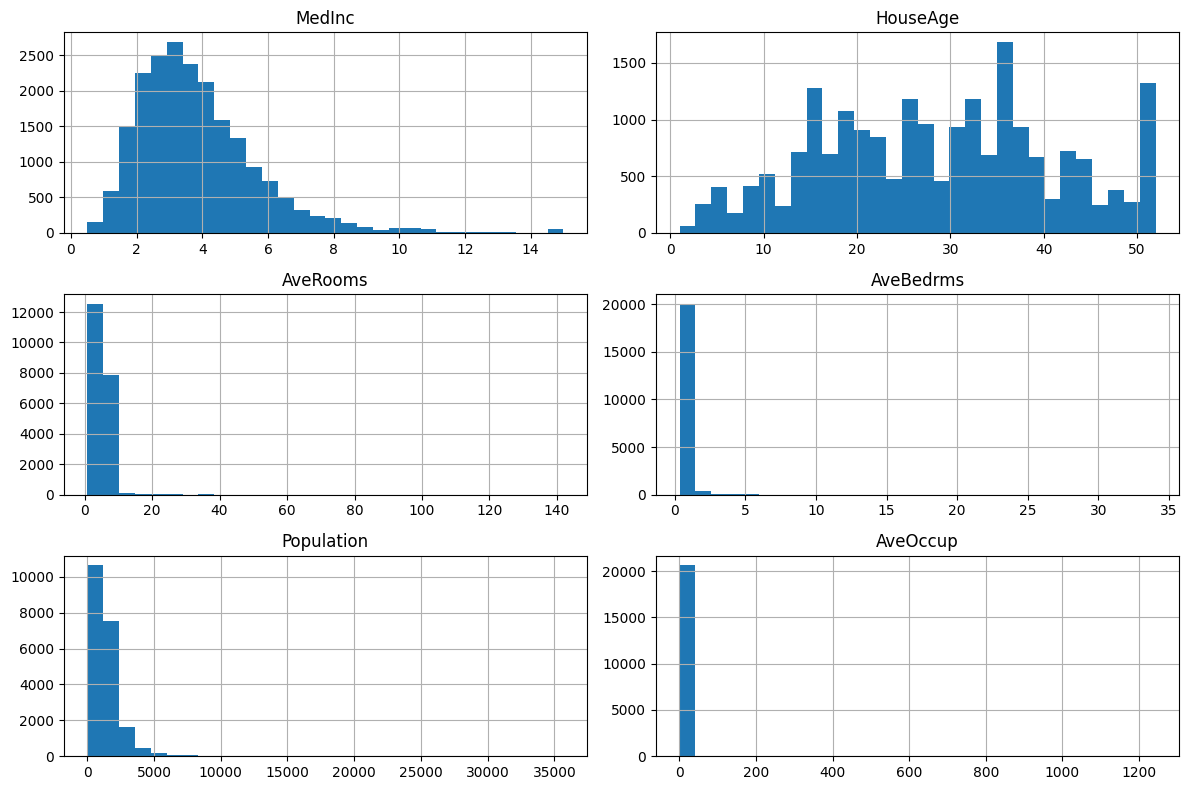

In [5]:
df.hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

6. Correlation Matrix

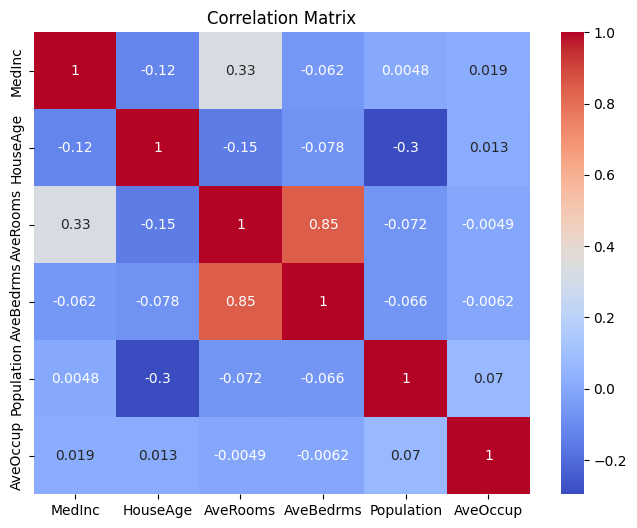

In [6]:

plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

7. Scatter Plot

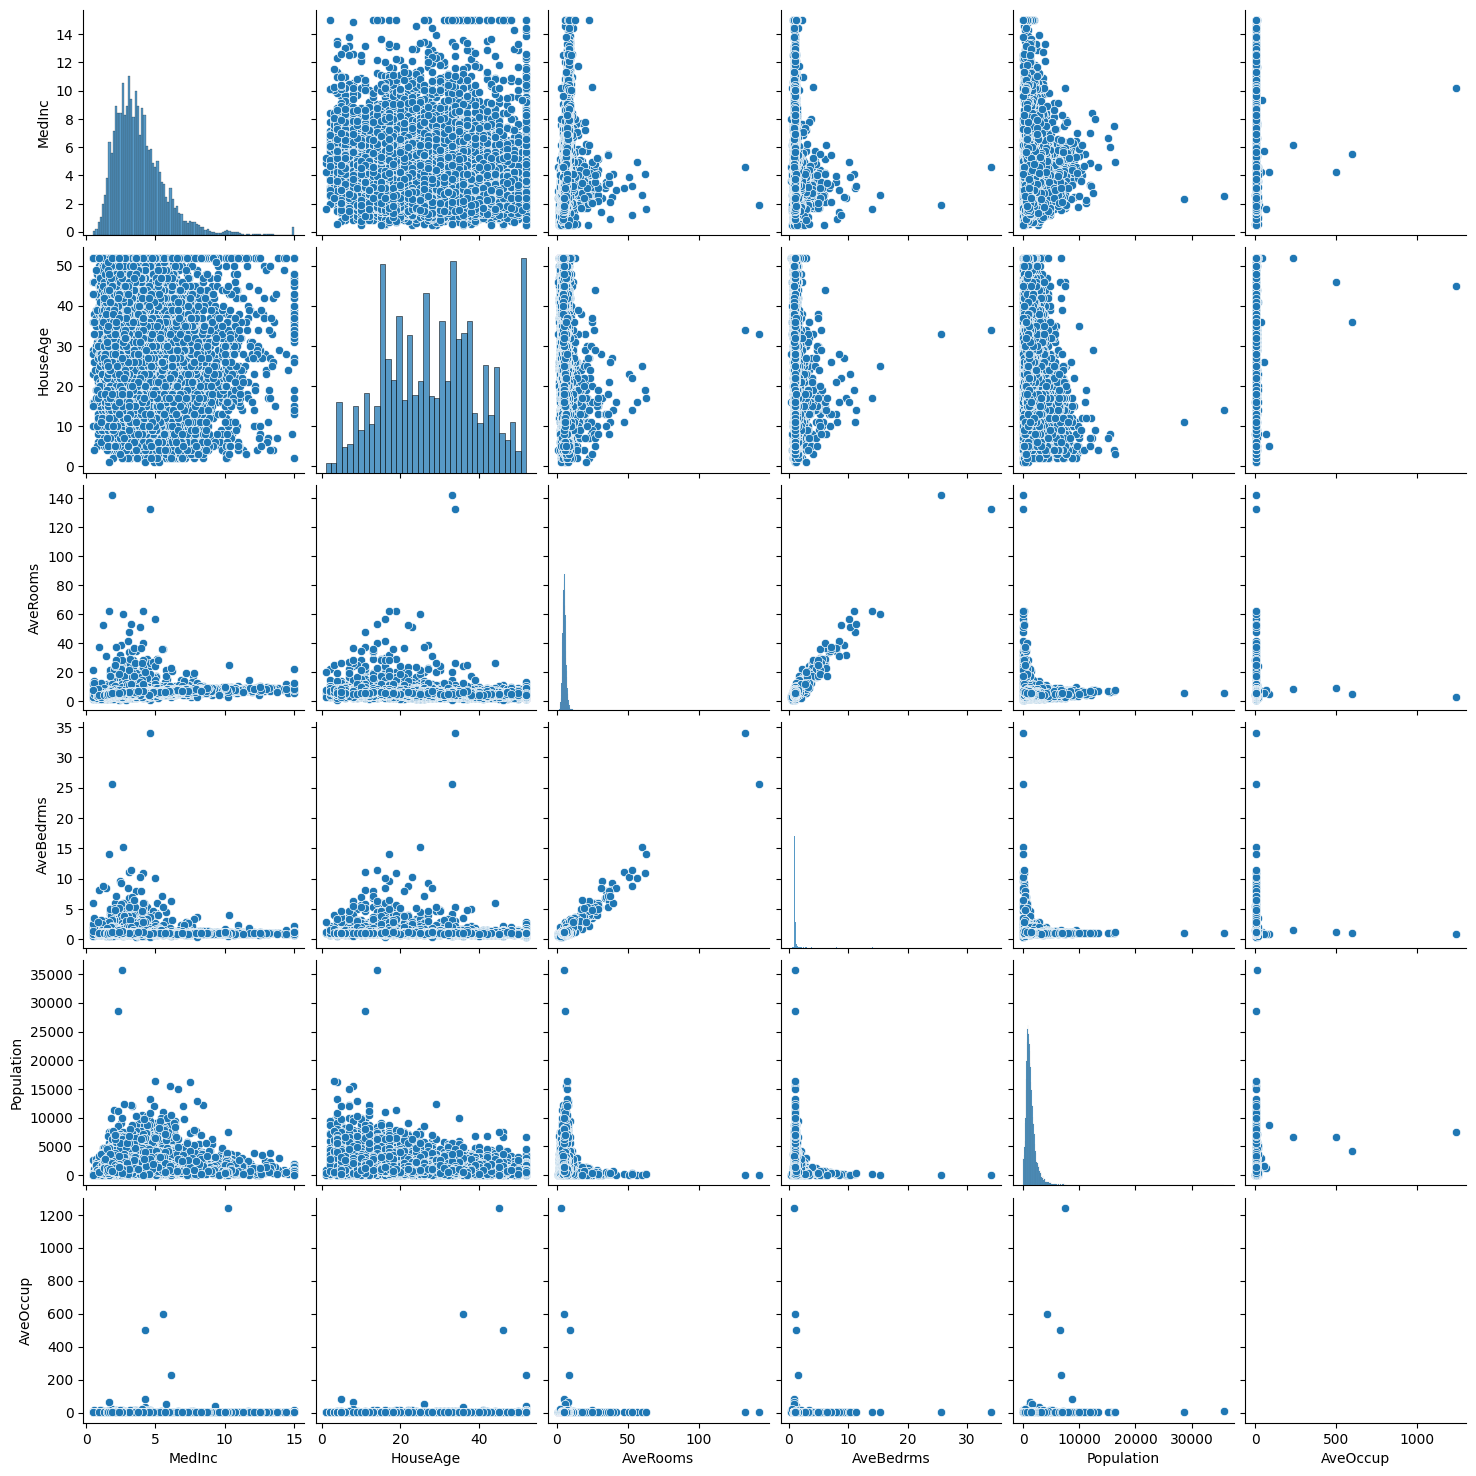

In [7]:
sns.pairplot(df)
plt.show()

# Data preprocessing

1. Check Missing Values

In [8]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
dtype: int64

2. Feature Scaling (value → (value - mean) / std)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)
X_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616


3. Verify Scaling

In [10]:
X_scaled.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04
mean,6.609700e-17,5.508083e-18,-2.533718e-16,-1.404561e-16,-1.101617e-17,1.032766e-17
std,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00
min,-1.774299e+00,-2.196180e+00,-1.852319e+00,-1.610768e+00,-1.256123e+00,-2.290000e-01
25%,-6.881186e-01,-8.453931e-01,-3.994496e-01,-1.911716e-01,-5.638089e-01,-6.171062e-02
50%,-1.767951e-01,2.864572e-02,-8.078489e-02,-1.010650e-01,-2.291318e-01,-2.431585e-02
75%,4.593063e-01,6.643103e-01,2.519615e-01,6.015869e-03,2.644949e-01,2.037453e-02
max,5.858286e+00,1.856182e+00,5.516324e+01,6.957171e+01,3.025033e+01,1.194191e+02


4. Outlier Detection

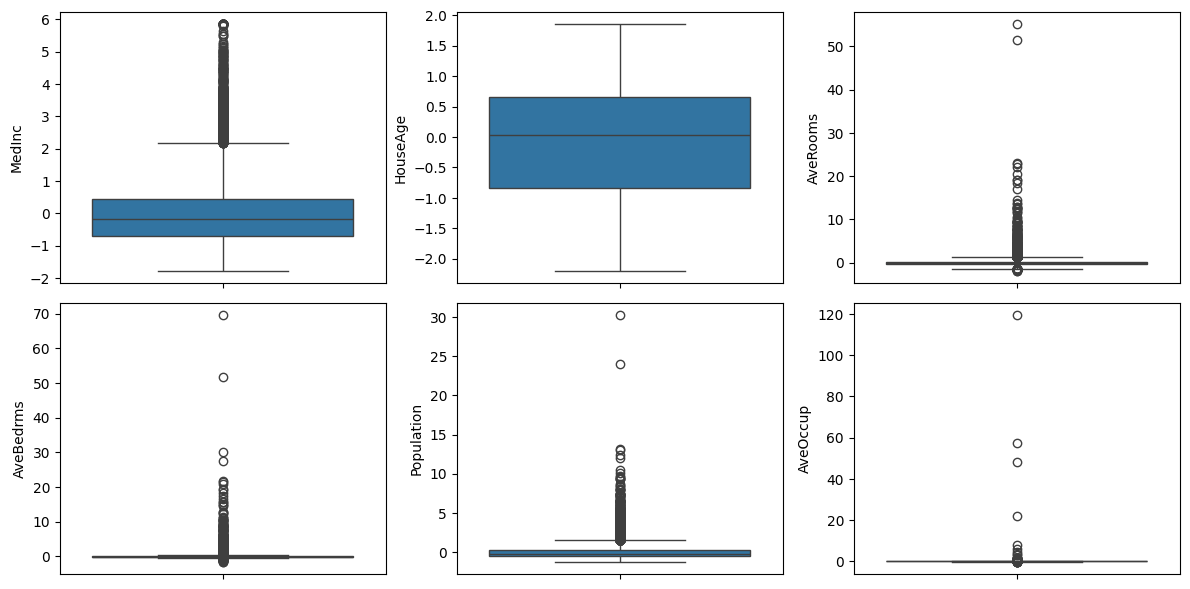

In [11]:

plt.figure(figsize=(12,6))

for i, col in enumerate(X_scaled.columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=X_scaled[col])

plt.tight_layout()
plt.show()

5. Remove Outliers (IQR Method)

In [12]:

Q1 = X_scaled.quantile(0.25)
Q3 = X_scaled.quantile(0.75)

IQR = Q3 - Q1

X_scaled = X_scaled[
    ~((X_scaled < (Q1 - 1.5 * IQR)) |
      (X_scaled > (Q3 + 1.5 * IQR))).any(axis=1)
]
print("After removing outliers:", X_scaled.shape)

After removing outliers: (16842, 6)


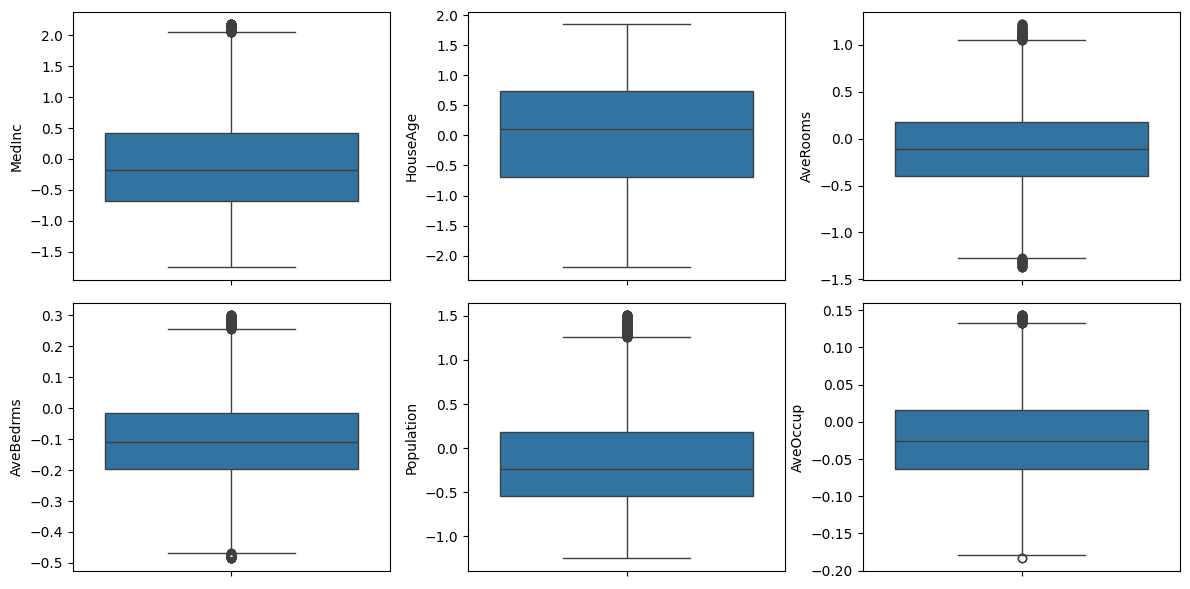

In [13]:

plt.figure(figsize=(12,6))

for i, col in enumerate(X_scaled.columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=X_scaled[col])

plt.tight_layout()
plt.show()

# K-Means

1. Elbow Method

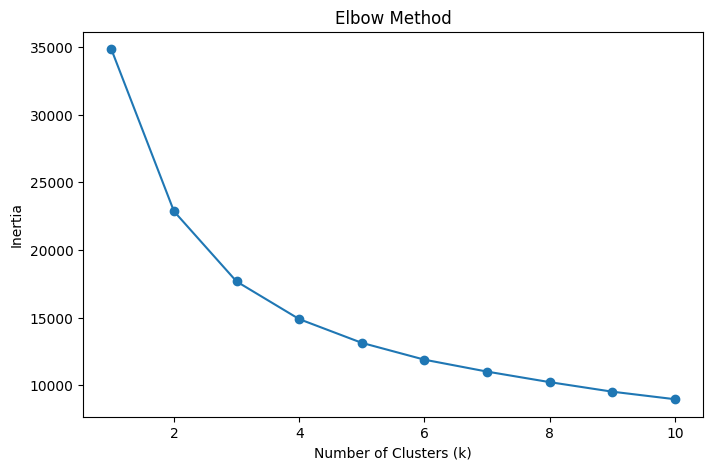

In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []


K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.show()

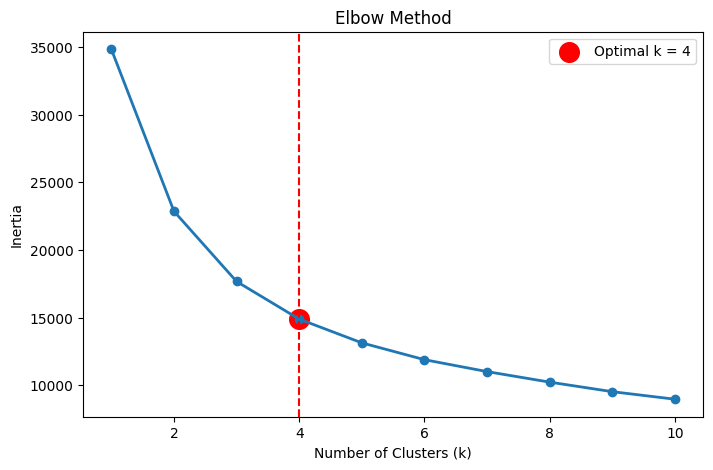

In [15]:

optimal_k = 4

plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o', linewidth=2)

plt.scatter(
    optimal_k,
    inertia[optimal_k - 1],
    color='red',
    s=200,
    label=f'Optimal k = {optimal_k}'
)


plt.axvline(
    x=optimal_k,
    color='red',
    linestyle='--'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.legend()

plt.show()

2. Train K-Means

In [16]:

kmeans = KMeans(n_clusters=optimal_k, random_state=42)


clusters_kmeans = kmeans.fit_predict(X_scaled)

X_scaled['KMeans_Cluster'] = clusters_kmeans

X_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,KMeans_Cluster
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,0
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,0
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,2
5,0.087447,1.856182,-0.269730,0.014669,-0.894071,-0.089618,2
6,-0.111366,1.856182,-0.200918,-0.306633,-0.292712,-0.090725,2


3. Silhouette Score

In [17]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(
    X_scaled.drop(columns=['KMeans_Cluster']),
    clusters_kmeans
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.2556425467840904


4. PCA Visualization

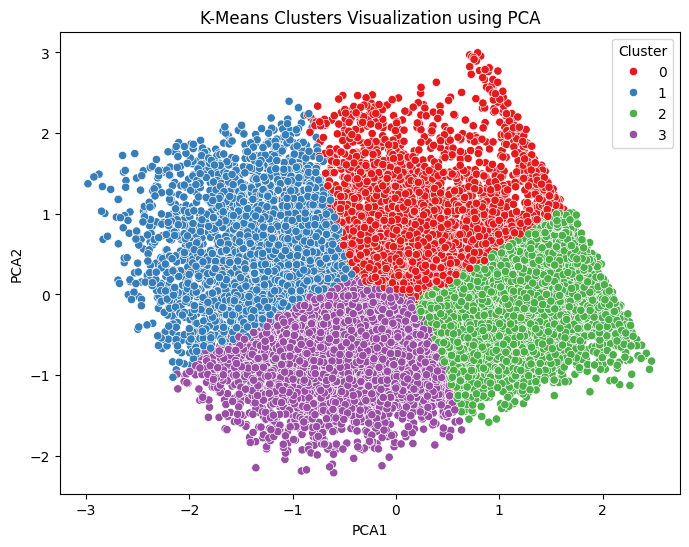

In [18]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_scaled.drop(columns=['KMeans_Cluster'])
)


pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])

pca_df['Cluster'] = clusters_kmeans

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("K-Means Clusters Visualization using PCA")

plt.show()

# DBSCAN

1. Apply DBSCAN

In [19]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=0.3, min_samples=5)


clusters_dbscan = dbscan.fit_predict(
    X_scaled.drop(columns=['KMeans_Cluster'])
)


X_scaled['DBSCAN_Cluster'] = clusters_dbscan


print(X_scaled['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0     15496
-1      1233
 1        19
 3        16
 10       14
 15        9
 4         8
 5         7
 9         5
 8         5
 13        4
 12        4
 6         4
 11        4
 7         4
 14        4
 16        3
 2         3
Name: count, dtype: int64


2. Evaluate DBSCAN

In [20]:
from sklearn.metrics import silhouette_score


dbscan_data = X_scaled[X_scaled['DBSCAN_Cluster'] != -1]

X_dbscan = dbscan_data.drop(
    columns=['KMeans_Cluster', 'DBSCAN_Cluster']
)


labels_dbscan = dbscan_data['DBSCAN_Cluster']

sil_dbscan = silhouette_score(X_dbscan, labels_dbscan)

print("DBSCAN Silhouette Score:", sil_dbscan)

DBSCAN Silhouette Score: -0.2561484454639482


3. PCA Visualization

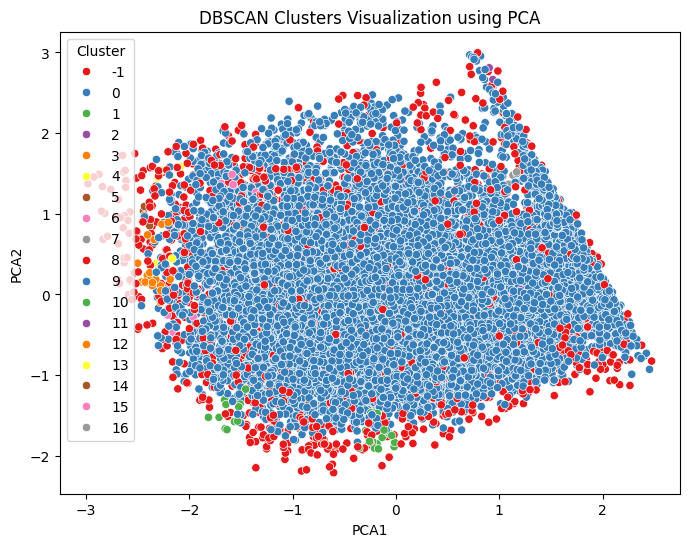

In [21]:

pca = PCA(n_components=2)

X_pca_db = pca.fit_transform(
    X_scaled.drop(columns=['KMeans_Cluster', 'DBSCAN_Cluster'])
)


pca_db = pd.DataFrame(X_pca_db, columns=['PCA1', 'PCA2'])

pca_db['Cluster'] = clusters_dbscan


plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_db,
    palette='Set1'
)

plt.title("DBSCAN Clusters Visualization using PCA")

plt.show()

4. Count Noise Points

In [22]:

noise_points = (clusters_dbscan == -1).sum()

print("Number of noise points:", noise_points)

Number of noise points: 1233


# Agglomerative Clustering

1. Apply Agglomerative Clustering

In [23]:
from sklearn.cluster import AgglomerativeClustering


agglomerative = AgglomerativeClustering(n_clusters=3)


clusters_agg = agglomerative.fit_predict(
    X_scaled.drop(
        columns=['KMeans_Cluster', 'DBSCAN_Cluster'],
        errors='ignore'
    )
)


X_scaled['Agglomerative_Cluster'] = clusters_agg


print(X_scaled['Agglomerative_Cluster'].value_counts())

Agglomerative_Cluster
2    7409
0    5285
1    4148
Name: count, dtype: int64


2. Silhouette Score

In [24]:
from sklearn.metrics import silhouette_score

# Features
X_agg = X_scaled.drop(
    columns=[
        'KMeans_Cluster',
        'DBSCAN_Cluster',
        'Agglomerative_Cluster'
    ],
    errors='ignore'
)

# Compute silhouette score
sil_agg = silhouette_score(X_agg, clusters_agg)

print("Agglomerative Silhouette Score:", sil_agg)

Agglomerative Silhouette Score: 0.21051186278608047


2. PCA Visualization

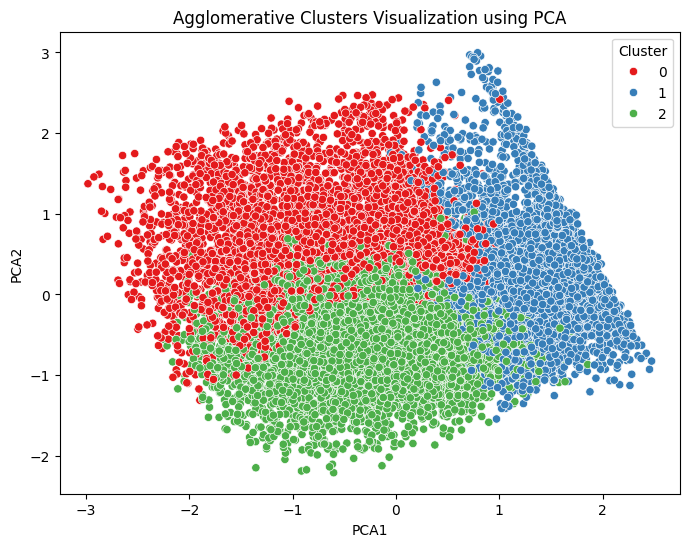

In [25]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)

X_pca_agg = pca.fit_transform(
    X_scaled.drop(
        columns=[
            'KMeans_Cluster',
            'DBSCAN_Cluster',
            'Agglomerative_Cluster'
        ],
        errors='ignore'
    )
)


pca_agg = pd.DataFrame(
    X_pca_agg,
    columns=['PCA1', 'PCA2']
)

pca_agg['Cluster'] = clusters_agg

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_agg,
    palette='Set1'
)

plt.title("Agglomerative Clusters Visualization using PCA")

plt.show()

3. Optional Dendrogram

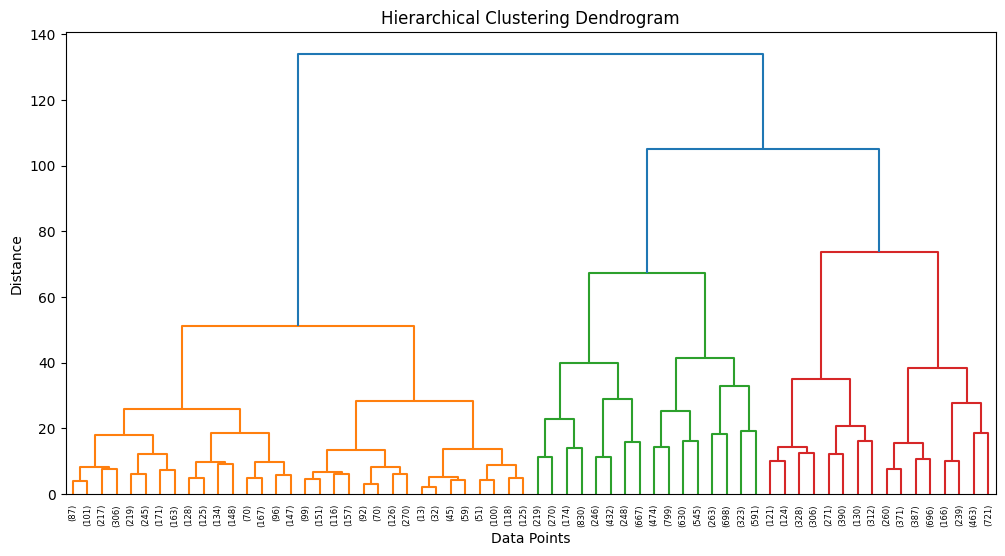

In [26]:
from scipy.cluster.hierarchy import dendrogram, linkage


linked = linkage(
    X_scaled.drop(
        columns=[
            'KMeans_Cluster',
            'DBSCAN_Cluster',
            'Agglomerative_Cluster'
        ],
        errors='ignore'
    ),
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(
    linked,
    truncate_mode='level',
    p=5
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

# Gaussian Mixture Models (GMM)

1. Apply GMM

In [27]:
from sklearn.mixture import GaussianMixture


gmm = GaussianMixture(
    n_components=3,
    random_state=42
)


clusters_gmm = gmm.fit_predict(
    X_scaled.drop(
        columns=[
            'KMeans_Cluster',
            'DBSCAN_Cluster',
            'Agglomerative_Cluster'
        ],
        errors='ignore'
    )
)

X_scaled['GMM_Cluster'] = clusters_gmm


print(X_scaled['GMM_Cluster'].value_counts())

GMM_Cluster
2    6616
1    5638
0    4588
Name: count, dtype: int64


2. Silhouette Score

In [28]:
from sklearn.metrics import silhouette_score


X_gmm = X_scaled.drop(
    columns=[
        'KMeans_Cluster',
        'DBSCAN_Cluster',
        'Agglomerative_Cluster',
        'GMM_Cluster'
    ],
    errors='ignore'
)


sil_gmm = silhouette_score(X_gmm, clusters_gmm)

print("GMM Silhouette Score:", sil_gmm)

GMM Silhouette Score: 0.22518656614271657


3. PCA Visualization

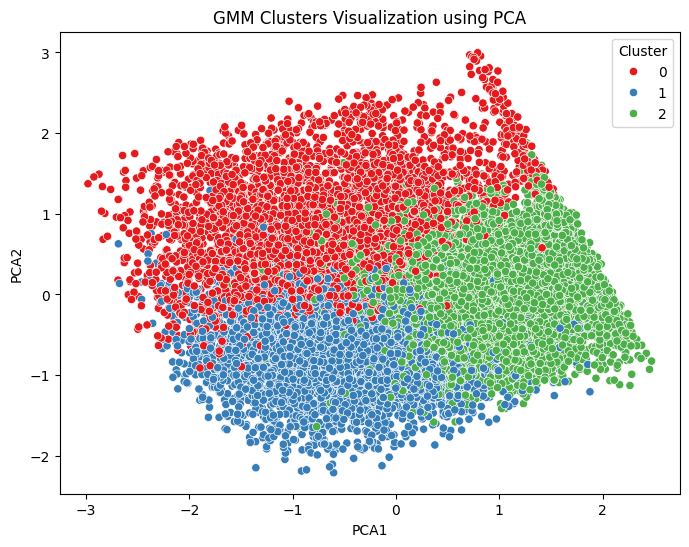

In [29]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)

X_pca_gmm = pca.fit_transform(
    X_scaled.drop(
        columns=[
            'KMeans_Cluster',
            'DBSCAN_Cluster',
            'Agglomerative_Cluster',
            'GMM_Cluster'
        ],
        errors='ignore'
    )
)

pca_gmm = pd.DataFrame(
    X_pca_gmm,
    columns=['PCA1', 'PCA2']
)

pca_gmm['Cluster'] = clusters_gmm


plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_gmm,
    palette='Set1'
)

plt.title("GMM Clusters Visualization using PCA")

plt.show()

4. Cluster Probabilities

In [30]:

probabilities = gmm.predict_proba(X_gmm)


print(probabilities[:5])

[[9.95182391e-01 7.44305430e-09 4.81760142e-03]
 [7.96520628e-01 1.07882480e-05 2.03468583e-01]
 [6.06288460e-02 1.09437973e-04 9.39261716e-01]
 [1.46923587e-01 6.20085477e-04 8.52456328e-01]
 [1.02391954e-01 6.19918749e-04 8.96988127e-01]]
